# Exercise 1: Numerical Integration Methods

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint

### Exercise 1.1: Simulate Dampled Pendulum Dynamics

The dynamics for a simple (damped) pendulum are defined by the second order equation:
\begin{equation}
\ddot{\theta} = -\frac{g}{l}\sin \theta - \gamma \dot{\theta},
\end{equation}
where $\theta$ is the angle of the pendulum with respect to the negative vertical axis, $g$ is the acceleration due to gravity, $l$ is the length of the pendulum, and $\gamma$ is a damping coefficient.
This second-order differential equation is equivalent to the system of first-order differential equations:
\begin{equation}
\dot{x}_0 = x_1, \quad \dot{x}_1 = -\frac{g}{l}\sin x_0 - \gamma x_1,
\end{equation}
where $x_0 = \theta$ and $x_1 = \dot{\theta}$.

Implement the damped pendulum dynamics in the function below:

In [2]:
def dampled_pendulum(x: np.ndarray, t: float, g: float=9.81, l: float=1., γ: float=1.) -> np.ndarray:
    """
    Evaluate pendulum dynamics.

    Args:
        x: state vector, [θ, dθ_dt]
        t: time [s]
        g: acceleration due to gravity [m/s^2]
        l: pendulum length [m]
        γ: damping coefficient [1/s]

    Returns:
        dx_dt : state vector derivative, [dθ_dt, d2θ_dt2]
    """
    ##### YOUR CODE STARTS HERE #####
    theta, dtheta_dt = x
    d2theta_dt2 = -(g/l * np.sin(theta)) - γ * dtheta_dt
    dx = np.array([dtheta_dt, d2theta_dt2])
    ###### YOUR CODE ENDS HERE ######
    return dx

We can simulate general robot motion models by solving the differential equations via numerical integration, for example using the Euler, midpoint, or Runge-Kutta methods. In Python, the `SciPy` package also offers a method for numerical integration called `odeint` that uses a more advanced method. Implement the call to `odeint` and run the code block below to simulate the damped pendulum.

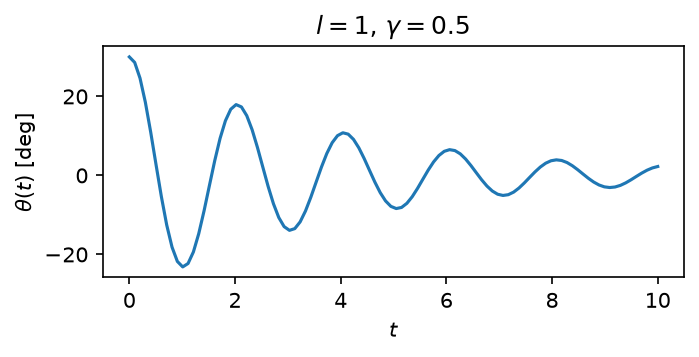

In [3]:
# Define IVP and model constants
θ0 = np.deg2rad(30.) # initial angle
x0 = np.array([θ0, 0.])
T = 10. # simulation time
l = 1 # pendulum length
γ = 0.5 # damping coefficient

# Use odeint to simulated the dynamics
t = np.linspace(0, T, num=100)
##### YOUR CODE STARTS HERE #####
# Compute x_odeint using SciPy's odeint function
x_odeint = odeint(dampled_pendulum, x0, t, args=(9.8, l, γ))
###### YOUR CODE ENDS HERE ######
θ_odeint, dθ_odeint = x_odeint.T

# Plot results
fig, ax = plt.subplots(1, 1, figsize=(5, 2), dpi=150)
ax.plot(t, np.rad2deg(θ_odeint))
ax.set_title(r'$l = $' + f'{l:g}, ' + r'$\gamma = $' + f'{γ:g}')
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$\theta(t)$ [deg]')
plt.show()

### Exercise 2: Simulate Bicycle Dynamics

A simple motion model for a bicycle/simple car is:
\begin{equation}
\dot{x} = v\cos\theta, \quad \dot{y} = v\sin\theta, \quad \dot{\theta} = \frac{v}{L}\tan\phi, 
\end{equation}
where $(x,y)$ is the position, $v$ is the speed control, $\theta$ is the heading angle, $L$ is the wheelbase length, and $\phi$ is the steering angle.
This is a controlled system with the control inputs being $u = [v, \phi]^\top$.
Here we can assume simple simple open-loop control with:
\begin{equation}
v = 1, \quad \phi = \sin(t).
\end{equation}

Implement the `open_loop_bicycle` function to model the bicycle/simple car dynamics with the specified open-loop controller.

In [4]:
def open_loop_bicycle(x: np.ndarray, t: float, L: float=1.) -> np.ndarray:
    """
    Evaluate bicycle dynamics with a simple open-loop control law.

    Args:
        x: state vector, [x, y, θ]
        t: time [s]
        L: wheelbase length [m]

    Returns:
        dx_dt: state vector derivative, [̇dx_dt, dy_dt, dθ_dt]
    """
    # Open-loop controller definition
    v = 1 # constant speed
    ϕ = np.sin(t)

    ##### YOUR CODE STARTS HERE #####
    ### Implement bicycle dynamics
    x, y, theta = x
    dx_dt = v * np.cos(theta)
    dy_dt = v * np.sin(theta)
    dtheta_dt = v / L * np.tan(ϕ)
    dx_dt = np.array([dx_dt, dy_dt, dtheta_dt])
    ###### YOUR CODE ENDS HERE ######
    return dx_dt

Implement the call to `odeint` for the bicycle dynamics and run the script below to simulate the dynamics.

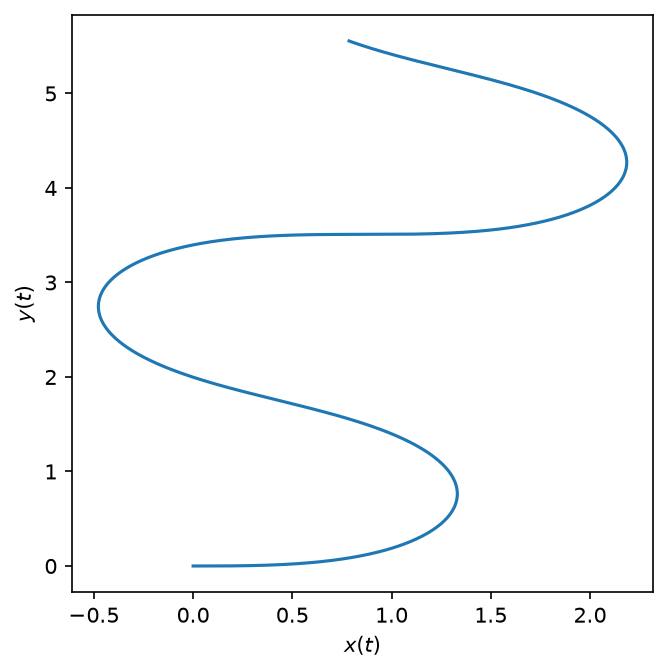

In [5]:
Δt = 0.01
T = 10. # simulation time
t = np.linspace(0, T, num=int(T/Δt))
x0 = np.array([0, 0, 0])

##### YOUR CODE STARTS HERE #####
# Compute x_bike using SciPy's odeint function
x_bike = odeint(open_loop_bicycle, x0, t)
###### YOUR CODE ENDS HERE ######
pos_x_bike, pos_y_bike, θ_bike = x_bike.T

# Plot results
fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=150)
ax.plot(pos_x_bike, pos_y_bike)
ax.set_xlabel(r'$x(t)$')
ax.set_ylabel(r'$y(t)$')
plt.show()